In [1]:
import ast
import pandas as pd
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt
from datasets import load_dataset

datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_Ind_ds = df[(df['job_country']=='India') & (df['job_title_short'] == 'Data Scientist')].copy()

In [3]:
df_Ind_ds['job_posted_month'] = df_Ind_ds['job_posted_date'].dt.month
df_Ind_ds

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
19,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Indeed,Full-time,False,India,2023-04-26 13:20:12,False,False,India,None,NaN,NaN,Bitwise Solutions,"[r, sql, python, scala, java, c++, hadoop, tab...","{'analyst_tools': ['tableau'], 'libraries': ['...",4
29,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Exusia,Full-time,False,India,2023-03-26 13:16:20,False,False,India,None,NaN,NaN,Exusia,None,None,3
239,Data Scientist,Power BI Data Analytics & Data Scientist,"Maharashtra, India",via Shine,Full-time,False,India,2023-11-11 13:10:08,False,False,India,None,NaN,NaN,Emerson,[power bi],{'analyst_tools': ['power bi']},11
323,Data Scientist,Forecasting Analyst,Anywhere,via LinkedIn,Full-time,True,India,2023-09-28 13:48:45,False,False,India,None,NaN,NaN,Straive,[excel],{'analyst_tools': ['excel']},9
389,Data Scientist,Data Scientist,"New Delhi, Delhi, India",via LinkedIn,Contractor,False,India,2023-09-12 13:16:27,False,False,India,None,NaN,NaN,Digital India Corporation,"[sql, sas, sas, excel, powerpoint, tableau]","{'analyst_tools': ['sas', 'excel', 'powerpoint...",9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785591,Data Scientist,Data Scientist T8,"Bengaluru, Karnataka, India",via BeBee India,Full-time,False,India,2023-01-01 06:29:03,False,False,India,None,NaN,NaN,Mercedes-Benz Research and Development India P...,"[java, python, aws, azure, kubernetes, docker,...","{'async': ['jira', 'confluence'], 'cloud': ['a...",1
785645,Data Scientist,Data Science Intern,Anywhere,via LinkedIn,Internship,True,India,2023-01-20 06:51:23,False,False,India,None,NaN,NaN,TwiLearn EduTech Pvt. Ltd.,"[python, tableau]","{'analyst_tools': ['tableau'], 'programming': ...",1
785654,Data Scientist,Data Science Intern,Anywhere,via LinkedIn,None,True,India,2023-01-31 06:11:46,False,False,India,None,NaN,NaN,Corizo,[zoom],{'sync': ['zoom']},1
785674,Data Scientist,Data Scientist,"Kolkata, West Bengal, India",via LinkedIn,Full-time,False,India,2023-01-12 06:12:32,False,False,India,None,NaN,NaN,One Billion Ideas Pvt. LTD.,"[r, python, sql, scala, java, c++, matplotlib,...","{'analyst_tools': ['tableau'], 'libraries': ['...",1


In [5]:
df_Ind_ds_ex= df_Ind_ds.explode('job_skills')

In [14]:
df_Ind_pivot = df_Ind_ds_ex.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_Ind_pivot.loc['Total'] = df_Ind_pivot.sum()
df_Ind_pivot = df_Ind_pivot[df_Ind_pivot.loc['Total'].sort_values(ascending=False).index]
df_Ind_pivot = df_Ind_pivot.drop('Total')

In [17]:
Ds_total = df_Ind_ds.groupby('job_posted_month').size()

In [18]:
df_Ind_ds_perc = df_Ind_pivot.div(Ds_total/100, axis=0)
df_Ind_ds_perc

job_skills,python,sql,r,aws,tableau,spark,tensorflow,azure,pytorch,hadoop,...,delphi,nuix,clickup,next.js,redhat,symphony,mlpack,codecommit,cobol,ringcentral
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,67.174515,48.684211,32.479224,18.628809,17.174515,16.551247,16.481994,15.096953,9.695291,13.434903,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,65.236052,45.600858,30.579399,15.987124,17.596567,16.523605,15.772532,12.875536,12.017167,12.982833,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,72.437811,51.741294,33.930348,18.507463,20.597015,19.303483,15.721393,14.427861,12.636816,14.427861,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.099502,0.000000,0.000000,0.099502,0.000000
4,68.181818,49.154334,33.509514,20.295983,19.344609,19.133192,18.181818,15.010571,13.742072,13.953488,...,0.105708,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.105708,0.000000,0.000000
5,71.923536,49.103943,29.510155,22.461171,20.191159,16.726404,15.053763,16.606930,12.305854,11.350060,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.119474,0.000000,0.000000,0.119474
6,74.579274,49.689991,34.366696,19.309123,17.006200,18.777679,18.777679,14.526129,13.994686,13.728964,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,69.367765,52.537845,34.194123,17.453250,19.412289,19.145147,17.631345,15.850401,13.535174,14.870882,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,68.625756,48.660328,34.053587,19.187554,20.656871,20.829732,18.409680,16.421780,13.483146,15.211755,...,0.000000,0.000000,0.08643,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,69.308943,44.613821,31.910569,19.817073,16.971545,15.345528,19.004065,19.004065,15.040650,12.601626,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [19]:
df_Ind_ds_perc = df_Ind_ds_perc.reset_index()
df_Ind_ds_perc['job_posted_month'] = df_Ind_ds_perc['job_posted_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_Ind_ds_perc = df_Ind_ds_perc.set_index('job_posted_month')
df_Ind_ds_perc

job_skills,python,sql,r,aws,tableau,spark,tensorflow,azure,pytorch,hadoop,...,delphi,nuix,clickup,next.js,redhat,symphony,mlpack,codecommit,cobol,ringcentral
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,67.174515,48.684211,32.479224,18.628809,17.174515,16.551247,16.481994,15.096953,9.695291,13.434903,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,65.236052,45.600858,30.579399,15.987124,17.596567,16.523605,15.772532,12.875536,12.017167,12.982833,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,72.437811,51.741294,33.930348,18.507463,20.597015,19.303483,15.721393,14.427861,12.636816,14.427861,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.099502,0.000000,0.000000,0.099502,0.000000
Apr,68.181818,49.154334,33.509514,20.295983,19.344609,19.133192,18.181818,15.010571,13.742072,13.953488,...,0.105708,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.105708,0.000000,0.000000
May,71.923536,49.103943,29.510155,22.461171,20.191159,16.726404,15.053763,16.606930,12.305854,11.350060,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.119474,0.000000,0.000000,0.119474
Jun,74.579274,49.689991,34.366696,19.309123,17.006200,18.777679,18.777679,14.526129,13.994686,13.728964,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,69.367765,52.537845,34.194123,17.453250,19.412289,19.145147,17.631345,15.850401,13.535174,14.870882,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,68.625756,48.660328,34.053587,19.187554,20.656871,20.829732,18.409680,16.421780,13.483146,15.211755,...,0.000000,0.000000,0.08643,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,69.308943,44.613821,31.910569,19.817073,16.971545,15.345528,19.004065,19.004065,15.040650,12.601626,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


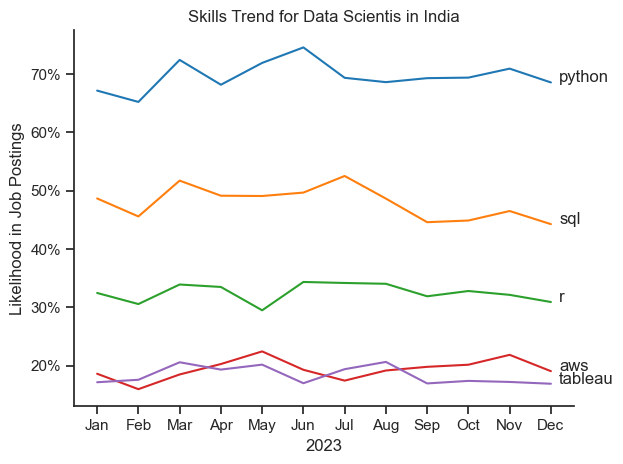

In [30]:
df_plot = df_Ind_ds_perc.iloc[:, :5]
sbs.lineplot(data=df_plot, dashes=False, palette='tab10')
sbs.set_theme(style='ticks')
plt.title('Skills Trend for Data Scientis in India')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Postings')
plt.legend().remove()

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1,i], df_plot.columns[i])

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
sbs.despine() 
plt.tight_layout()   